# Stage-1 PINN: training + outcome analysis

Self-contained and re-entrant.  This notebook

1. assembles the BBG section-4 problem (20 calls, frozen Greeks, vega slab),
2. builds / loads the reduced-2D reference,
3. trains the **structure-blind** PINN (pure MLP over $(t,\nu,q)$ — no
   $\mathcal{V}^\top q$ feature, no constraint features), resuming from
   `checkpoints/pinn_stage1_smoke.pkl` when present,
4. analyses the outcome: value collapse onto the $\mathcal{V}^\pi$ line,
   hyperplane discovery ($\nabla_q v \parallel \mathcal{V}$), value error
   vs the reference, quote-level comparison, and residual diagnostics with a
   light adversarial ascent.

**Profiles.** A CUDA device switches to the H200 budget (bigger net, long
Adam, GN-CG polish); otherwise the CPU smoke budget runs in minutes.  All
heavy phases checkpoint, so interrupting and re-running is cheap.

Mathematical conventions: `docs/derivations.md`.  Measured baseline numbers:
`docs/VALIDATION.md`.

In [1]:
# --- setup, profile, paths -------------------------------------------------
import os, sys, time, pickle
from pathlib import Path

import jax, jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    assert ROOT != ROOT.parent, 'run from inside the optmm repo'
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
CKPT_DIR = ROOT / 'checkpoints'; CKPT_DIR.mkdir(exist_ok=True)
CKPT = CKPT_DIR / 'pinn_stage1_smoke.pkl'
REF_NPZ = CKPT_DIR / 'ref2d_full.npz'

import optmm  # noqa: F401  (enforces float64)

ON_GPU = any(d.platform == 'gpu' for d in jax.devices())
PROFILE = dict(
    name='h200' if ON_GPU else 'cpu-smoke',
    hidden=(128, 128, 128) if ON_GPU else (64, 64, 64),
    train_steps=60_000 if ON_GPU else 6_000,     # fresh-start budget
    resume_steps=20_000 if ON_GPU else 500,      # top-up when resuming
    batch=4096 if ON_GPU else 256,
    lr=1e-3,
    gn_iters=40 if ON_GPU else 0,                # GN-CG polish: GPU only
    gn_batch=8192 if ON_GPU else 0,
    ref_nt=1440, ref_NV=801,                     # value reference
    q_nt=1440 if ON_GPU else 720,                # quote/slice reference
    q_NV=401 if ON_GPU else 201,
)
print('devices:', jax.devices())
print('profile:', PROFILE)

devices: [CpuDevice(id=0)]
profile: {'name': 'cpu-smoke', 'hidden': (64, 64, 64), 'train_steps': 6000, 'resume_steps': 500, 'batch': 256, 'lr': 0.001, 'gn_iters': 0, 'gn_batch': 0, 'ref_nt': 1440, 'ref_NV': 801, 'q_nt': 720, 'q_NV': 201}


## 1. Problem assembly

BBG section 4 verbatim: $S_0=10$, $\nu_0=0.0225$,
$\kappa^\mathbb{P}=2,\ \theta^\mathbb{P}=0.04$,
$\kappa^\mathbb{Q}=3,\ \theta^\mathbb{Q}=0.0225$, $\xi=0.2$,
$\rho=-0.5$; 20 calls $K\in\{8..12\}\times T\in\{1,1.5,2,3\}$;
logistic intensities with $k_i=\beta/\mathcal{V}^i$; trade sizes
$z^i = 5\cdot10^5/O^i_0$; $\bar V = 10^7$, $T=0.0012$, $\gamma=10^{-3}$,
$\Delta$-neutral hedge ($c=0$, $m(c)=1$).

In [2]:
from optmm.core.risk import BBG_MARKET, penalty_coef
from optmm.instruments.book import build_bbg_book
from optmm.solvers.reduced2d import Channels, solve_reduced2d, _bc
from optmm.solvers.pinn.model import PinnSpec, init_params, value
from optmm.solvers.pinn.train import (make_loss, adam_train, gn_polish,
                                      sample_batch, collinearity,
                                      value_error_vs_reference)

GAMMA, VBAR, T = 1e-3, 1e7, 0.0012
book = build_bbg_book(BBG_MARKET)
ch = Channels.from_book(book)
spec = PinnSpec(T=T, nu_lo=0.0144, nu_hi=0.0324,
                w=jnp.asarray(book.w), Vbar=VBAR, hidden=PROFILE['hidden'])
loss_fn, batched_res = make_loss(spec, ch, BBG_MARKET, GAMMA, 0.0, VBAR)
N = book.n_options

hdr = f"{'K':>4} {'tau':>4} {'price':>8} {'vega':>7} {'z':>9} {'w=z*vega':>10} {'lam/yr':>7}"
print(hdr); print('-' * len(hdr))
for i in range(N):
    print(f"{float(book.K[i]):>4.0f} {float(book.tau[i]):>4.1f} "
          f"{float(book.O0[i]):>8.4f} {float(book.vega[i]):>7.4f} "
          f"{float(book.z[i]):>9.0f} {float(book.w[i]):>10.3e} "
          f"{float(book.lam[i]):>7.0f}")
print(f"\nmax w / Vbar = {float(jnp.max(book.w))/VBAR:.3f}   "
      f"pen = {penalty_coef(GAMMA, BBG_MARKET.xi, BBG_MARKET.rho, 0.0):.2e}")

   K  tau    price    vega         z   w=z*vega  lam/yr
-------------------------------------------------------
   8  1.0   2.0597  0.4167    242752  1.012e+05    3150
   9  1.0   1.2178  0.9139    410593  3.752e+05    4447
  10  1.0   0.5860  1.2524    853210  1.069e+06    7560
  11  1.0   0.2178  1.0592   2295671  2.432e+06    4447
  12  1.0   0.0613  0.5592   8159598  4.563e+06    3150
   8  1.5   2.1124  0.4707    236703  1.114e+05    3150
   9  1.5   1.3193  0.8389    378985  3.179e+05    4447
  10  1.5   0.7182  1.0617    696188  7.391e+05    7560
  11  1.5   0.3342  0.9732   1496095  1.456e+06    4447
  12  1.5   0.1322  0.6621   3782721  2.504e+06    3150
   8  2.0   2.1664  0.4784    230800  1.104e+05    3150
   9  2.0   1.4098  0.7627    354668  2.705e+05    4447
  10  2.0   0.8300  0.9269    602380  5.583e+05    7560
  11  2.0   0.4388  0.8837   1139390  1.007e+06    4447
  12  2.0   0.2082  0.6789   2401193  1.630e+06    3150
   8  3.0   2.2725  0.4604    220026  1.013e+05 

## 2. Reference solutions

Two reduced-2D solves: a refined **value reference** ($NV=801$, cached to
`checkpoints/ref2d_full.npz`) and a moderate **quote/slice reference** with
stored time slices for the error-vs-$t$ analysis.  Their own error budget is
quantified in `docs/VALIDATION.md` (interpolation: ~3–20 EUR at these
resolutions; Euler-in-time: first order, ~1–2 EUR at the center).

In [3]:
t0 = time.time()
if REF_NPZ.exists():
    _r = np.load(REF_NPZ)
    ref_V, ref_row = _r['V_grid'], _r['v_row']
    print(f'value reference loaded from cache ({REF_NPZ.name})')
else:
    _sol = solve_reduced2d(book, BBG_MARKET, GAMMA, VBAR, T,
                           nt=PROFILE['ref_nt'], n_nu=31, n_V=PROFILE['ref_NV'])
    ref_V, ref_row = np.asarray(_sol.V_grid), np.asarray(_sol.v0[15])
    np.savez(REF_NPZ, V_grid=ref_V, v_row=ref_row, v0=np.asarray(_sol.v0))
    print(f'value reference solved in {time.time()-t0:.0f}s and cached')
v_center = float(np.interp(0.0, ref_V, ref_row))
print(f'v_ref(0, nu0, Vpi=0) = {v_center:,.0f} EUR')

t0 = time.time()
qsol = solve_reduced2d(book, BBG_MARKET, GAMMA, VBAR, T,
                       nt=PROFILE['q_nt'], n_nu=31, n_V=PROFILE['q_NV'],
                       store_stride=max(PROFILE['q_nt'] // 8, 1))
print(f'quote/slice reference solved in {time.time()-t0:.0f}s '
      f'({len(qsol.hist_t)} stored slices)')
I_NU = 15  # nu0 row

value reference loaded from cache (ref2d_full.npz)
v_ref(0, nu0, Vpi=0) = 164,059 EUR


quote/slice reference solved in 31s (9 stored slices)


## 3. Training (re-entrant)

Fresh start: `train_steps` of Adam.  If the checkpoint exists **and** its
architecture matches the profile, resume and top up with `resume_steps`.
On GPU the GN-CG polish runs afterwards — flagged honestly: that code path
compiles but has not been exercised at scale (see README).

resumed from pinn_stage1_smoke.pkl; topping up 500 steps


  adam     0: loss 2.8285e+13 (rms 5.318e+06)


  adam    41: loss 5.3691e+13 (rms 7.327e+06)


  adam    82: loss 4.5017e+13 (rms 6.709e+06)


  adam   123: loss 3.2425e+13 (rms 5.694e+06)


...

  adam   369: loss 3.5792e+13 (rms 5.983e+06)


  adam   410: loss 3.2553e+13 (rms 5.705e+06)


  adam   451: loss 2.6628e+13 (rms 5.160e+06)


  adam   492: loss 2.9209e+13 (rms 5.405e+06)


  adam   499: loss 3.0645e+13 (rms 5.536e+06)
adam: 47s
checkpoint saved -> /home/claude/optmm/checkpoints/pinn_stage1_smoke.pkl


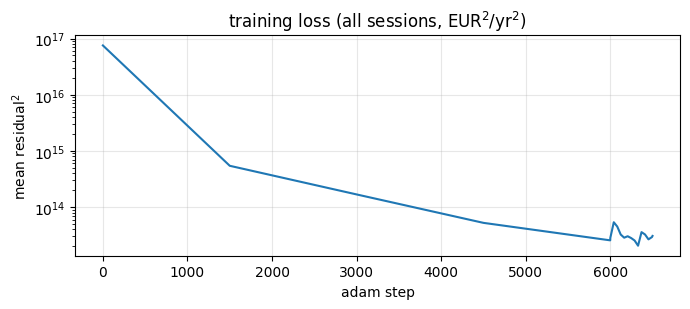

residual RMS: 5.536e+06 EUR/yr (x T = 6642.9 EUR over the horizon, naive bound)


In [4]:
key = jax.random.PRNGKey(0)
key, k0 = jax.random.split(key)
loss_hist = []
if CKPT.exists():
    with open(CKPT, 'rb') as f:
        saved = pickle.load(f)
    if tuple(saved.get('spec', {}).get('hidden', ())) == tuple(PROFILE['hidden']) \
       or tuple(saved.get('hidden', ())) == tuple(PROFILE['hidden']):
        params = jax.tree_util.tree_map(jnp.asarray, saved['params'])
        loss_hist = list(saved.get('loss_hist', []))
        steps = PROFILE['resume_steps']
        print(f'resumed from {CKPT.name}; topping up {steps} steps')
    else:
        params = init_params(spec, k0); steps = PROFILE['train_steps']
        print('checkpoint architecture mismatch -> fresh start')
else:
    params = init_params(spec, k0); steps = PROFILE['train_steps']
    print(f'fresh start: {steps} steps')

t0 = time.time()
off = loss_hist[-1][0] + 1 if loss_hist else 0
params, hist = adam_train(params, loss_fn, spec, key, steps=steps,
                          batch=PROFILE['batch'], lr=PROFILE['lr'],
                          log_every=max(steps // 12, 1))
loss_hist += [(off + i, l) for i, l in hist]
print(f'adam: {time.time()-t0:.0f}s')
if PROFILE['gn_iters']:
    t0 = time.time()
    params = gn_polish(params, batched_res, spec, key,
                       iters=PROFILE['gn_iters'], batch=PROFILE['gn_batch'])
    print(f'gn-cg polish: {time.time()-t0:.0f}s')

with open(CKPT, 'wb') as f:
    pickle.dump({'params': jax.tree_util.tree_map(np.asarray, params),
                 'spec': {'hidden': tuple(PROFILE['hidden']),
                          'v_scale': spec.v_scale},
                 'loss_hist': loss_hist}, f)
print(f'checkpoint saved -> {CKPT}')

fig, ax = plt.subplots(figsize=(7, 3.2))
xs, ys = zip(*loss_hist)
ax.semilogy(xs, ys, lw=1.5)
ax.set_xlabel('adam step'); ax.set_ylabel('mean residual$^2$')
ax.set_title('training loss (all sessions, EUR$^2$/yr$^2$)')
ax.grid(alpha=.3); plt.tight_layout(); plt.show()
print(f'residual RMS: {ys[-1]**0.5:.3e} EUR/yr '
      f'(x T = {ys[-1]**0.5*T:.1f} EUR over the horizon, naive bound)')

## 4. Outcome analysis

### 4a. Value collapse onto the $\mathcal{V}^\pi$ line

The exact reduction says $v(t,\nu,q) = f(t,\nu,\mathcal{V}^\top q)$.
The PINN was never told this.  Scatter $v_\theta(0,\nu_0,n)$ for random
slab states against $\mathcal{V}^\pi = w^\top n$: collapse onto the 2-D
reference curve is structure discovery at the value level; the spread at
fixed $\mathcal{V}^\pi$ measures how much spurious gross-composition
dependence remains.

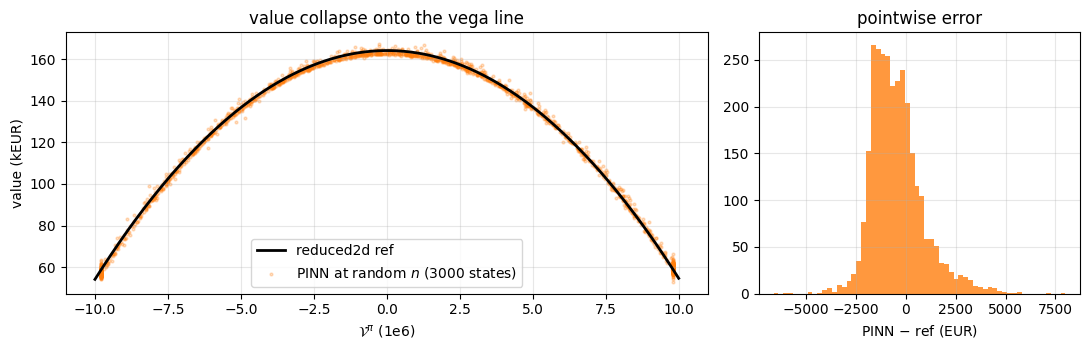

median |err| 997 EUR | max |err| 7,997 EUR | center scale 164,059 EUR
within-bin spread at fixed Vpi (median over bins): 1,923 EUR — spurious gross-composition dependence


In [5]:
key, ks = jax.random.split(key)
_, _, n_s = sample_batch(ks, spec, 3000, slab_frac=0.98)
Vpi_s = np.asarray(n_s @ spec.w)
v_pinn = np.asarray(jax.vmap(
    lambda m: value(params, spec, 0.0, BBG_MARKET.nu0, m))(n_s))
v_ref_at = np.interp(Vpi_s, ref_V, ref_row)
err_s = v_pinn - v_ref_at

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6),
                         gridspec_kw={'width_ratios': [2, 1]})
o = np.argsort(Vpi_s)
axes[0].plot(ref_V / 1e6, ref_row / 1e3, 'k-', lw=2, label='reduced2d ref')
axes[0].scatter(Vpi_s / 1e6, v_pinn / 1e3, s=4, alpha=.25, c='tab:orange',
                label=r'PINN at random $n$ (3000 states)')
axes[0].set_xlabel(r'$\mathcal{V}^\pi$ (1e6)'); axes[0].set_ylabel('value (kEUR)')
axes[0].set_title('value collapse onto the vega line'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].hist(err_s, bins=60, color='tab:orange', alpha=.8)
axes[1].set_xlabel('PINN $-$ ref (EUR)'); axes[1].set_title('pointwise error')
axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# spread at fixed Vpi: bin and measure within-bin std of v_pinn
bins = np.linspace(-VBAR, VBAR, 41)
ib = np.clip(np.digitize(Vpi_s, bins) - 1, 0, 39)
spread = [np.std(v_pinn[ib == b]) for b in range(40) if (ib == b).sum() > 10]
print(f'median |err| {np.median(np.abs(err_s)):,.0f} EUR | '
      f'max |err| {np.max(np.abs(err_s)):,.0f} EUR | '
      f'center scale {v_center:,.0f} EUR')
print(f'within-bin spread at fixed Vpi (median over bins): '
      f'{np.median(spread):,.0f} EUR — spurious gross-composition dependence')

### 4b. Hyperplane discovery: $\nabla_n v \parallel w$

The gradient direction cosine against $w$, over interior states.  Median at
1.0 means the network has recovered the risk geometry; the scatter against
$|\mathcal{V}^\pi|$ shows whether alignment degrades toward the slab
boundary (where the admissibility kinks live).

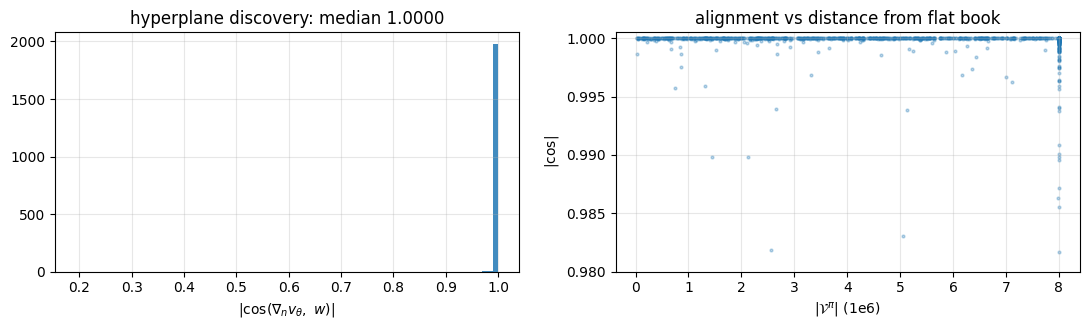

median |cos| = 0.99999;  fraction > 0.99: 0.990


In [6]:
key, kc = jax.random.split(key)
med_cos, cosv = collinearity(params, spec, kc, n_samples=2000)
_, _, n_c = sample_batch(jax.random.PRNGKey(int(np.asarray(kc)[0]) % 2**31),
                         spec, 2000, slab_frac=0.8)
Vpi_c = np.abs(np.asarray(n_c @ spec.w))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(np.abs(cosv), bins=80, color='tab:blue', alpha=.85)
axes[0].set_xlabel(r'$|\cos(\nabla_n v_\theta,\ w)|$')
axes[0].set_title(f'hyperplane discovery: median {med_cos:.4f}')
axes[0].grid(alpha=.3)
axes[1].scatter(Vpi_c / 1e6, np.abs(cosv), s=4, alpha=.3)
axes[1].set_xlabel(r'$|\mathcal{V}^\pi|$ (1e6)'); axes[1].set_ylabel(r'$|\cos|$')
axes[1].set_ylim(min(0.98, np.quantile(np.abs(cosv), .01)), 1.0005)
axes[1].set_title('alignment vs distance from flat book'); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f'median |cos| = {med_cos:.5f};  fraction > 0.99: '
      f'{np.mean(np.abs(cosv) > .99):.3f}')

### 4c. Value error across $\mathcal{V}^\pi$ and across time

Binned |error| against the refined reference at $t=0$, and the same metric
at the stored intermediate slices of the quote reference (which is itself
inexact at the few-EUR level — differences below that are noise).

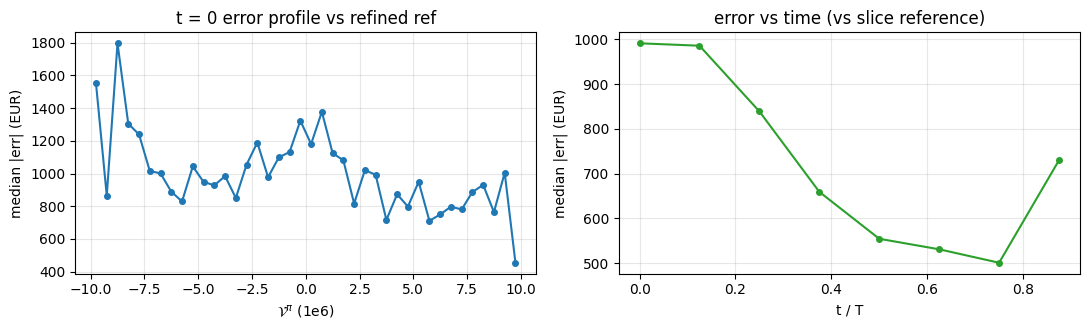

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ctrs = 0.5 * (bins[1:] + bins[:-1])
mabs = [np.median(np.abs(err_s[ib == b])) if (ib == b).sum() > 5 else np.nan
        for b in range(40)]
axes[0].plot(ctrs / 1e6, mabs, 'o-', ms=4)
axes[0].set_xlabel(r'$\mathcal{V}^\pi$ (1e6)')
axes[0].set_ylabel('median |err| (EUR)')
axes[0].set_title('t = 0 error profile vs refined ref'); axes[0].grid(alpha=.3)

ts, med_t = [], []
key, kt = jax.random.split(key)
_, _, n_t = sample_batch(kt, spec, 800, slab_frac=0.9)
Vpi_t = np.asarray(n_t @ spec.w)
for j, tj in enumerate(np.asarray(qsol.hist_t)[:-1]):  # skip t=T (both zero)
    vj = np.asarray(jax.vmap(
        lambda m: value(params, spec, float(tj), BBG_MARKET.nu0, m))(n_t))
    rj = np.interp(Vpi_t, np.asarray(qsol.V_grid), np.asarray(qsol.v_hist[j][I_NU]))
    ts.append(float(tj) / T); med_t.append(np.median(np.abs(vj - rj)))
axes[1].plot(ts, med_t, 'o-', ms=4, color='tab:green')
axes[1].set_xlabel('t / T'); axes[1].set_ylabel('median |err| (EUR)')
axes[1].set_title('error vs time (vs slice reference)'); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### 4d. Quote-level comparison

What the desk actually consumes.  PINN quotes come from value differences,
$\delta^{*}$ at $p = [v_\theta(n) - v_\theta(n \mp e_i)]/z_i$, evaluated
along a single-instrument ray and — the sharper test — at **random gross
compositions of equal $\mathcal{V}^\pi$**, where the exact quotes must
coincide.

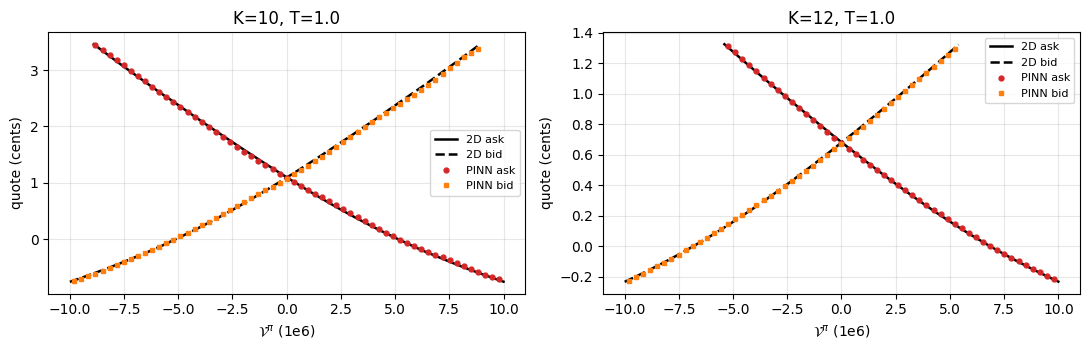

quote collapse at Vpi = 0.4 Vbar, ATM ask: PINN mean 0.226c +/- 0.014c across 196 gross compositions (2D ref 0.214c)
ATM ask, ray vs 2D: median |err| 0.016c, max 0.030c


In [8]:
def pinn_quotes(states, t_eval=0.0, nu_eval=None):
    nu_eval = BBG_MARKET.nu0 if nu_eval is None else nu_eval
    S = states.shape[0]
    inst = np.concatenate([np.arange(N), np.arange(N)])
    psi = np.concatenate([np.ones(N), -np.ones(N)])
    eye = np.eye(N)
    shifts = jnp.asarray(-psi[:, None] * eye[inst])          # (2N, N)
    v0 = jax.vmap(lambda m: value(params, spec, t_eval, nu_eval, m))(states)
    vsh = jax.vmap(lambda m: jax.vmap(
        lambda s: value(params, spec, t_eval, nu_eval, m + s))(shifts))(states)
    p = (v0[:, None] - vsh) / ch.z[None, :]                  # (S, 2N)
    d = _bc(ch.intensity, 1).argmax_delta(p.T, -5.0)         # (2N, S)
    Vpi_tgt = (states @ spec.w)[None, :] + shifts @ spec.w[:, None] * 0 \
        + (shifts @ spec.w)[:, None]
    adm = jnp.abs(Vpi_tgt) <= VBAR * (1 + 1e-12)
    return np.asarray(jnp.where(adm, d, jnp.nan))

IDX_SHOW = [2, 4]           # ATM T=1 and K=12 T=1
q2d = np.asarray(qsol.quotes())                              # (2N, n_nu, NV)
Vq = np.asarray(qsol.V_grid)
ray_i = 2                                                    # ATM T=1 ray
smax = VBAR / float(book.w[ray_i])
ss = np.linspace(-smax * .98, smax * .98, 61)
ray = jnp.asarray(np.outer(ss, np.eye(N)[ray_i]))
q_ray = pinn_quotes(ray)
Vpi_ray = ss * float(book.w[ray_i])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
for ax_, i in zip(axes, IDX_SHOW):
    ax_.plot(Vq / 1e6, 1e2 * q2d[i, I_NU], 'k-', lw=1.8, label='2D ask')
    ax_.plot(Vq / 1e6, 1e2 * q2d[N + i, I_NU], 'k--', lw=1.8, label='2D bid')
    ax_.plot(Vpi_ray / 1e6, 1e2 * q_ray[i], 'o', ms=3.5, c='tab:red',
             label='PINN ask')
    ax_.plot(Vpi_ray / 1e6, 1e2 * q_ray[N + i], 's', ms=3.5, c='tab:orange',
             label='PINN bid')
    ax_.set_title(f'K={float(book.K[i]):.0f}, T={float(book.tau[i]):.1f}')
    ax_.set_xlabel(r'$\mathcal{V}^\pi$ (1e6)'); ax_.set_ylabel('quote (cents)')
    ax_.grid(alpha=.3); ax_.legend(fontsize=8)
plt.tight_layout(); plt.show()

# quote collapse: many random compositions at the same Vpi
key, kq = jax.random.split(key)
target = 0.4 * VBAR
dirs = jax.random.uniform(kq, (200, N), minval=-1., maxval=1.)
n_rand = dirs * (target / (dirs @ spec.w))[:, None]
keep = np.max(np.abs(np.asarray(n_rand) * np.asarray(book.w)[None, :]),
              axis=1) < 3 * VBAR      # drop wild cancellations
q_rand = pinn_quotes(jnp.asarray(np.asarray(n_rand)[keep]))
ask_std = np.nanstd(q_rand[IDX_SHOW[0]]) * 1e2
ask_2d = float(np.interp(target, Vq, q2d[IDX_SHOW[0], I_NU])) * 1e2
print(f'quote collapse at Vpi = 0.4 Vbar, ATM ask: '
      f'PINN mean {np.nanmean(q_rand[IDX_SHOW[0]])*1e2:.3f}c '
      f'+/- {ask_std:.3f}c across {int(keep.sum())} gross compositions '
      f'(2D ref {ask_2d:.3f}c)')
err_ask = 1e2 * (q_ray[IDX_SHOW[0]] - np.interp(Vpi_ray, Vq, q2d[IDX_SHOW[0], I_NU]))
print(f'ATM ask, ray vs 2D: median |err| {np.nanmedian(np.abs(err_ask)):.3f}c, '
      f'max {np.nanmax(np.abs(err_ask)):.3f}c')

### 4e. Residual diagnostics + light adversarial ascent

Pool max/median of $|R|$, a heatmap over $(\nu, \mathcal{V}^\pi)$ along
the ATM ray at $t=0$, and a few projected-gradient ascent steps from the
worst pool points — a cheap preview of the stage-2 certificate machinery.
Units: EUR/yr; multiplying by $T$ bounds the naive per-state value impact.

pool |R|: median 3.149e+06, max 3.926e+07 EUR/yr (x T: 47112.1 EUR naive)


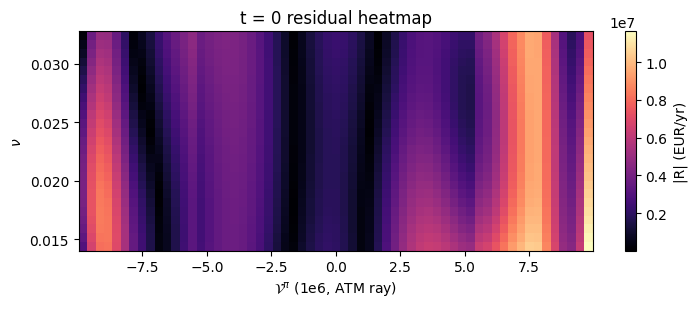

adversarial ascent: pool-worst 3.926e+07 -> ascended 7.410e+07 EUR/yr (amplification x1.89)


In [9]:
from optmm.solvers.pinn.residual import residual_stage1
pen = penalty_coef(GAMMA, BBG_MARKET.xi, BBG_MARKET.rho, 0.0)
res_pt = lambda t, nu, n: residual_stage1(params, spec, value, ch, BBG_MARKET,
                                          pen, VBAR, t, nu, n)
key, kp = jax.random.split(key)
tp, nup, npnts = sample_batch(kp, spec, 4000)
R = np.asarray(jax.vmap(res_pt)(tp, nup, npnts))
print(f'pool |R|: median {np.median(np.abs(R)):.3e}, '
      f'max {np.max(np.abs(R)):.3e} EUR/yr '
      f'(x T: {np.max(np.abs(R))*T:.1f} EUR naive)')

nus = np.linspace(spec.nu_lo, spec.nu_hi, 25)
Rmap = np.zeros((25, len(ss)))
for a, nu_a in enumerate(nus):
    Rmap[a] = np.abs(np.asarray(jax.vmap(
        lambda m: res_pt(0.0, float(nu_a), m))(ray)))
fig, ax = plt.subplots(figsize=(7.5, 3.2))
im = ax.pcolormesh(Vpi_ray / 1e6, nus, Rmap, shading='auto', cmap='magma')
plt.colorbar(im, label='|R| (EUR/yr)')
ax.set_xlabel(r'$\mathcal{V}^\pi$ (1e6, ATM ray)'); ax.set_ylabel(r'$\nu$')
ax.set_title('t = 0 residual heatmap'); plt.tight_layout(); plt.show()

# adversarial ascent from the worst pool points
worst = np.argsort(-np.abs(R))[:16]
g_R2 = jax.jit(jax.grad(lambda t, nu, n: res_pt(t, nu, n) ** 2, argnums=(0, 1, 2)))
t_a, nu_a, n_a = tp[worst], nup[worst], npnts[worst]
for it in range(25):
    gt, gn_, gm = jax.vmap(g_R2)(t_a, nu_a, n_a)
    sc = 1.0 / (jnp.abs(jax.vmap(res_pt)(t_a, nu_a, n_a)) + 1e-9)
    t_a = jnp.clip(t_a + 1e-9 * sc * gt, 0.0, T)
    nu_a = jnp.clip(nu_a + 1e-7 * sc * gn_, spec.nu_lo, spec.nu_hi)
    n_a = n_a + 3e-2 * sc[:, None] * gm / (jnp.linalg.norm(gm, axis=1, keepdims=True) + 1e-30)
    Vp = n_a @ spec.w
    n_a = n_a * jnp.minimum(1.0, 0.98 * VBAR / (jnp.abs(Vp) + 1e-30))[:, None]
R_adv = np.asarray(jax.vmap(res_pt)(t_a, nu_a, n_a))
print(f'adversarial ascent: pool-worst {np.max(np.abs(R[worst])):.3e} -> '
      f'ascended {np.max(np.abs(R_adv)):.3e} EUR/yr '
      f'(amplification x{np.max(np.abs(R_adv))/np.max(np.abs(R[worst])):.2f})')

## 5. Verdict

Headline metrics printed above; on the CPU-smoke budget the recorded
baselines (docs/VALIDATION.md) are: hyperplane discovery median
$|\cos| = 1.0000$ (99% of samples $>0.99$), center value error ~0.8%,
loss still descending — the discovery claim is already demonstrated, the
value/quote accuracy is budget-limited.

Honest caveats: (i) the reduced2d reference is itself inexact at the
few-EUR level (quantified in VALIDATION.md via the exact commensurable-atom
construction), so sub-EUR PINN comparisons are meaningless here — the exact
lattice ladder is the stage-2 instrument for that; (ii) the adversarial
ascent above is a smoke-scale preview, not a certificate; (iii) the GN-CG
polish path is compiled-but-unexercised until the first H200 run.  Re-run
this notebook on the H200 profile for full-budget numbers.